# Sprint 25 — Plots de présentation
## Tâches natives PC : Régression RUL + Multi-classe

**Expériences couvertes** : `exp_S25_01` à `exp_S25_05`

| Exp | Modèle | Dataset | Tâche |
|-----|--------|---------|-------|
| S25_01 | EWC Regression | CMAPSS | RUL continu (4 sets FD001–FD004) |
| S25_02 | EWC Regression | Pronostia | RUL continu (3 roulements) |
| S25_03 | EWC Multi-class | CWRU | 10 classes de défauts |
| S25_04 | HDC Regressor | CMAPSS | RUL continu (comparaison avec EWC) |
| S25_05 | Profiling RAM | Tous | Empreinte mémoire nouveaux modèles |

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

ROOT = Path("..")
EXP = ROOT / "experiments"
FIG_DIR = EXP / "figures" / "sprint25"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

PALETTE = {"EWC": "#2196F3", "HDC": "#4CAF50"}

# Chargement des JSONs
def load(exp_id):
    path = EXP / exp_id / "results.json"
    with open(path) as f:
        return json.load(f)

s25_01 = load("exp_S25_01")  # EWC Reg CMAPSS
s25_02 = load("exp_S25_02")  # EWC Reg Pronostia
s25_03 = load("exp_S25_03")  # EWC Multi-class CWRU
s25_04 = load("exp_S25_04")  # HDC Reg CMAPSS
s25_05 = load("exp_S25_05")  # Memory profiling

print("Données chargées ✅")

Données chargées ✅


## 1. Régression RUL — RMSE par tâche (CMAPSS 4 sets)

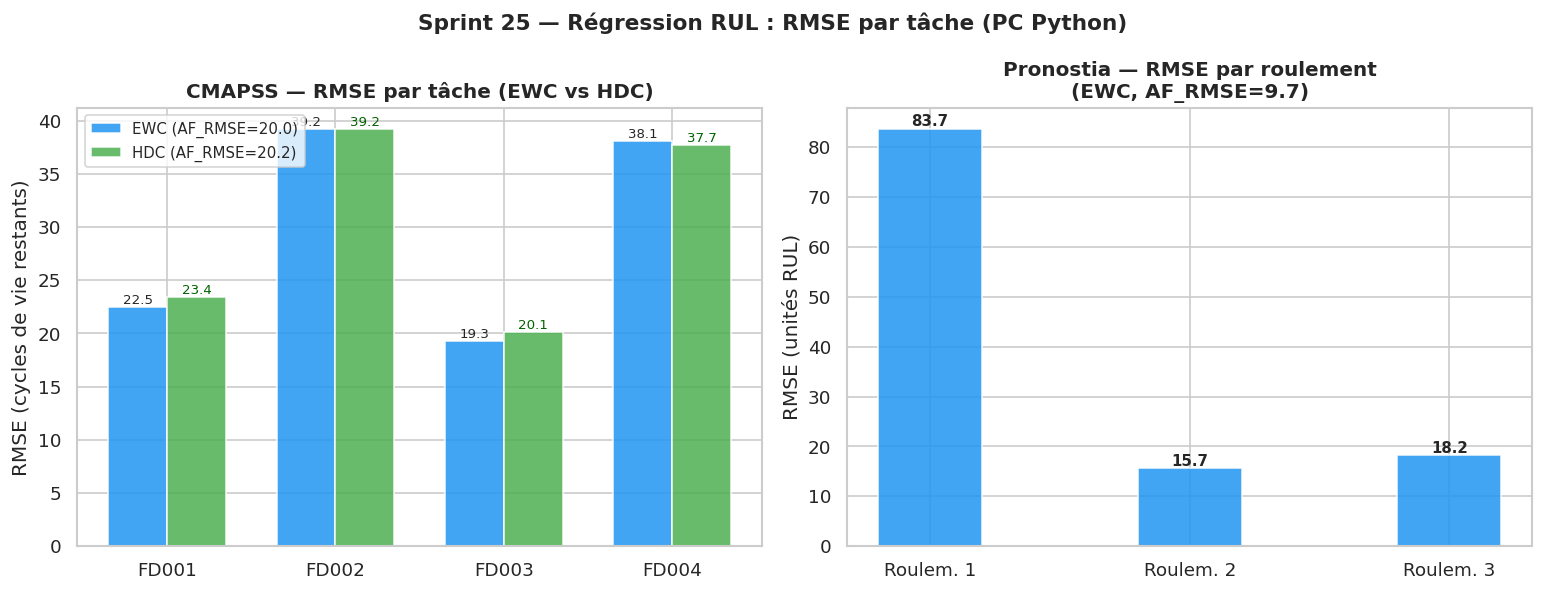

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# EWC vs HDC sur CMAPSS
task_names = [f"FD00{t['task_id']}" for t in s25_01["per_task_metrics"]]
rmse_ewc = [t["rmse"] for t in s25_01["per_task_metrics"]]
rmse_hdc = [t["rmse"] for t in s25_04["per_task_metrics"]]

ax = axes[0]
x = np.arange(len(task_names))
w = 0.35
b1 = ax.bar(x - w/2, rmse_ewc, w, label=f"EWC (AF_RMSE={s25_01['avg_forgetting_rmse']:.1f})",
            color=PALETTE["EWC"], alpha=0.85)
b2 = ax.bar(x + w/2, rmse_hdc, w, label=f"HDC (AF_RMSE={s25_04['avg_forgetting_rmse']:.1f})",
            color=PALETTE["HDC"], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(task_names)
ax.set_ylabel("RMSE (cycles de vie restants)")
ax.set_title("CMAPSS — RMSE par tâche (EWC vs HDC)", fontweight="bold")
ax.legend(fontsize=9)
for bar, v in zip(b1, rmse_ewc):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f"{v:.1f}", ha="center", fontsize=8)
for bar, v in zip(b2, rmse_hdc):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f"{v:.1f}", ha="center", fontsize=8,
            color="darkgreen")

# Pronostia
ax = axes[1]
p_tasks = [f"Roulem. {t['task_id']}" for t in s25_02["per_task_metrics"]]
p_rmse  = [t["rmse"] for t in s25_02["per_task_metrics"]]
bars = ax.bar(p_tasks, p_rmse, color=PALETTE["EWC"], width=0.4, edgecolor="white", alpha=0.85)
for bar, v in zip(bars, p_rmse):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f"{v:.1f}", ha="center",
            fontsize=9, fontweight="bold")
ax.set_ylabel("RMSE (unités RUL)")
ax.set_title(f"Pronostia — RMSE par roulement\n(EWC, AF_RMSE={s25_02['avg_forgetting_rmse']:.1f})",
             fontweight="bold")

fig.suptitle("Sprint 25 — Régression RUL : RMSE par tâche (PC Python)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "rul_rmse_by_task.png", bbox_inches="tight")
plt.show()

## 2. Horizon Score — CMAPSS (capacité à anticiper les pannes à horizon fixe)

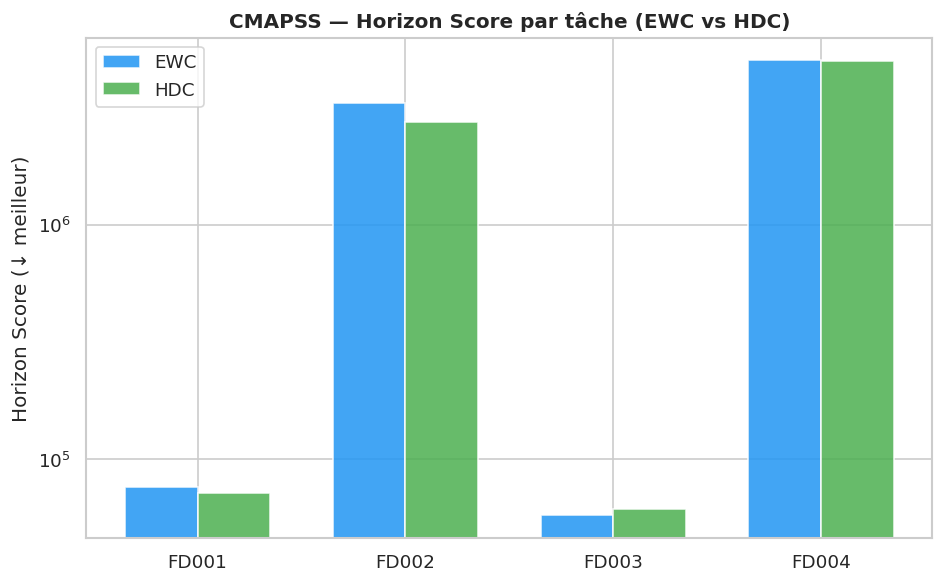

Note : FD002/FD004 ont un Horizon Score élevé car conditions opérationnelles variables.


In [3]:
# Horizon score (plus petit = meilleur : pénalise les prédictions en retard)
task_names = [f"FD00{t['task_id']}" for t in s25_01["per_task_metrics"]]
hs_ewc = [t["horizon_score"] for t in s25_01["per_task_metrics"]]
hs_hdc = [t["horizon_score"] for t in s25_04["per_task_metrics"]]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(task_names))
w = 0.35
ax.bar(x - w/2, hs_ewc, w, label="EWC", color=PALETTE["EWC"], alpha=0.85)
ax.bar(x + w/2, hs_hdc, w, label="HDC", color=PALETTE["HDC"], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(task_names)
ax.set_ylabel("Horizon Score (↓ meilleur)")
ax.set_yscale("log")
ax.set_title("CMAPSS — Horizon Score par tâche (EWC vs HDC)", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "horizon_score_cmapss.png", bbox_inches="tight")
plt.show()
print("Note : FD002/FD004 ont un Horizon Score élevé car conditions opérationnelles variables.")

## 3. Multi-classe CWRU — F1-macro progressif par tâche

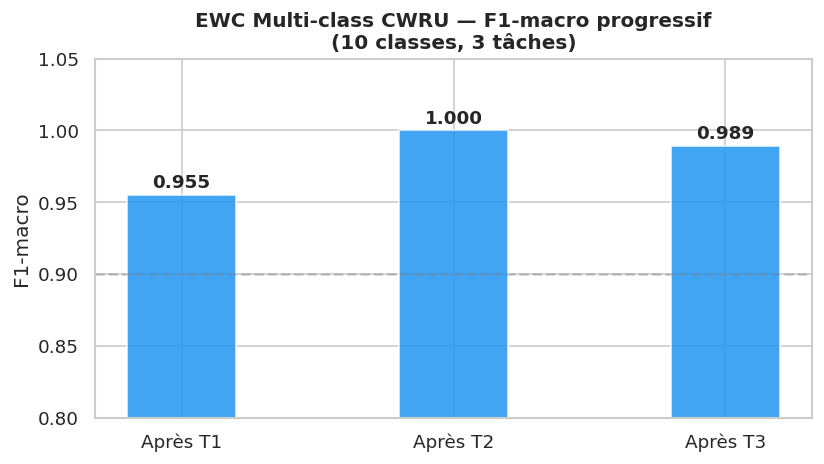

In [4]:
f1_tasks = [t["f1_macro"] for t in s25_03["per_task_metrics"]]
task_labels = [f"Après T{i+1}" for i in range(len(f1_tasks))]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(task_labels, f1_tasks, color="#2196F3", width=0.4, edgecolor="white", alpha=0.85)
for bar, v in zip(bars, f1_tasks):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f"{v:.3f}",
            ha="center", fontsize=11, fontweight="bold")

ax.set_ylim(0.8, 1.05)
ax.set_ylabel("F1-macro")
ax.set_title(
    f"EWC Multi-class CWRU — F1-macro progressif\n"
    f"({s25_03['n_classes']} classes, {s25_03['n_tasks']} tâches)",
    fontweight="bold"
)
ax.axhline(0.9, color="gray", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(FIG_DIR / "multiclass_cwru_f1_progression.png", bbox_inches="tight")
plt.show()

## 4. F1 per class — CWRU (tâche 3, vision complète 10 classes)

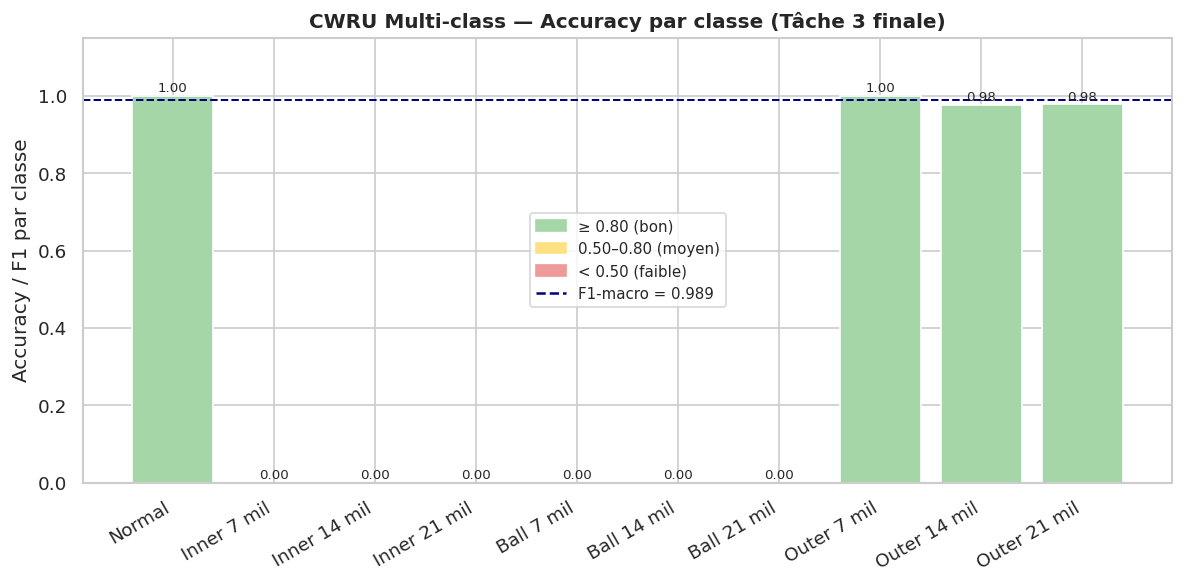

In [5]:
# Tâche finale (la plus informative, toutes les classes vues)
last_task = s25_03["per_task_metrics"][-1]
per_class = last_task.get("per_class_accuracy", {})

if per_class:
    # Noms des classes CWRU
    class_names = {
        "class_0": "Normal",
        "class_1": "Inner 7 mil",
        "class_2": "Inner 14 mil",
        "class_3": "Inner 21 mil",
        "class_4": "Ball 7 mil",
        "class_5": "Ball 14 mil",
        "class_6": "Ball 21 mil",
        "class_7": "Outer 7 mil",
        "class_8": "Outer 14 mil",
        "class_9": "Outer 21 mil",
    }
    labels = [class_names.get(k, k) for k in sorted(per_class.keys())]
    values = [per_class[k] if isinstance(per_class[k], (int, float))
              and not (isinstance(per_class[k], float) and np.isnan(per_class[k]))
              else 0.0
              for k in sorted(per_class.keys())]

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#A5D6A7" if v >= 0.8 else "#FFE082" if v >= 0.5 else "#EF9A9A"
              for v in values]
    bars = ax.bar(range(len(labels)), values, color=colors, edgecolor="white")
    for bar, v in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.2f}",
                ha="center", fontsize=8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylim(0, 1.15)
    ax.axhline(last_task["f1_macro"], color="navy", linestyle="--", linewidth=1.2,
               label=f"F1-macro global = {last_task['f1_macro']:.3f}")
    ax.set_ylabel("Accuracy / F1 par classe")
    ax.set_title("CWRU Multi-class — Accuracy par classe (Tâche 3 finale)", fontweight="bold")
    ax.legend(fontsize=9)

    # Légende couleurs
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(color="#A5D6A7", label="≥ 0.80 (bon)"),
        Patch(color="#FFE082", label="0.50–0.80 (moyen)"),
        Patch(color="#EF9A9A", label="< 0.50 (faible)"),
    ]
    ax.legend(handles=legend_elements + [
        plt.Line2D([0],[0], color="navy", linestyle="--",
                   label=f"F1-macro = {last_task['f1_macro']:.3f}")
    ], fontsize=9)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "cwru_per_class_accuracy.png", bbox_inches="tight")
    plt.show()
else:
    print("Pas de données per_class_accuracy pour cette tâche")

## 5. RAM profiling — nouveaux modèles Sprint 25

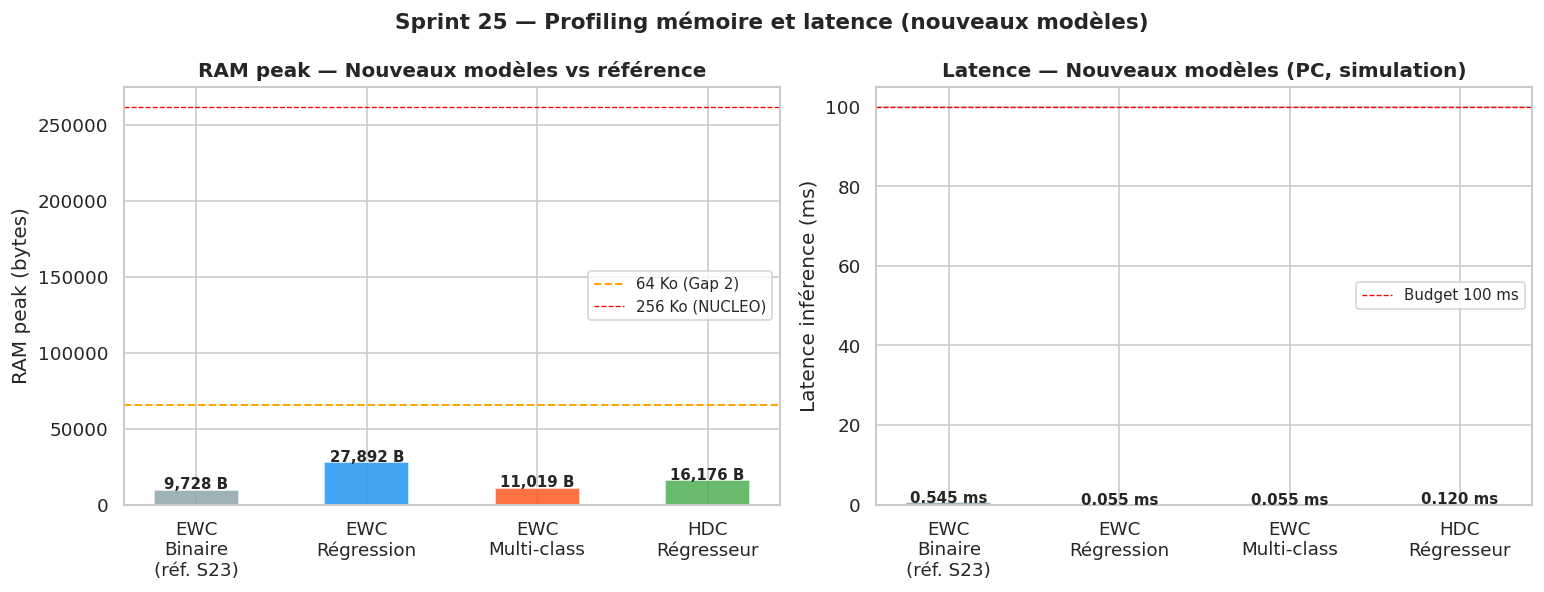

In [6]:
models_info = s25_05["models"]
ref = s25_05["reference_ewc_binary"]

names  = ["EWC\nBinaire\n(réf. S23)",
          "EWC\nRégression", "EWC\nMulti-class", "HDC\nRégresseur"]
rams   = [ref["ram_peak_bytes"],
          models_info["ewc_regression"]["ram_peak_bytes"],
          models_info["ewc_multiclass"]["ram_peak_bytes"],
          models_info["hdc_regressor"]["ram_peak_bytes"]]
lats   = [0.545,  # EWC binaire S23
          models_info["ewc_regression"]["inference_latency_ms"],
          models_info["ewc_multiclass"]["inference_latency_ms"],
          models_info["hdc_regressor"]["inference_latency_ms"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# RAM
ax = axes[0]
colors = ["#90A4AE", "#2196F3", "#FF5722", "#4CAF50"]
bars = ax.bar(names, rams, color=colors, width=0.5, edgecolor="white", alpha=0.85)
ax.axhline(65536,  color="orange", linestyle="--", linewidth=1.2, label="64 Ko (Gap 2)")
ax.axhline(262144, color="red",    linestyle="--", linewidth=0.8, label="256 Ko (NUCLEO)")
for bar, v in zip(bars, rams):
    ax.text(bar.get_x()+bar.get_width()/2, v+400, f"{v:,} B",
            ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("RAM peak (bytes)")
ax.set_title("RAM peak — Nouveaux modèles vs référence", fontweight="bold")
ax.legend(fontsize=9)

# Latence
ax = axes[1]
bars = ax.bar(names, lats, color=colors, width=0.5, edgecolor="white", alpha=0.85)
ax.axhline(100, color="red", linestyle="--", linewidth=0.8, label="Budget 100 ms")
for bar, v in zip(bars, lats):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.001, f"{v:.3f} ms",
            ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Latence inférence (ms)")
ax.set_title("Latence — Nouveaux modèles (PC, simulation)", fontweight="bold")
ax.legend(fontsize=9)

fig.suptitle("Sprint 25 — Profiling mémoire et latence (nouveaux modèles)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "s25_memory_latency_profiling.png", bbox_inches="tight")
plt.show()

## 6. RAM vs Accuracy — Trade-off taille/performance (tous modèles)

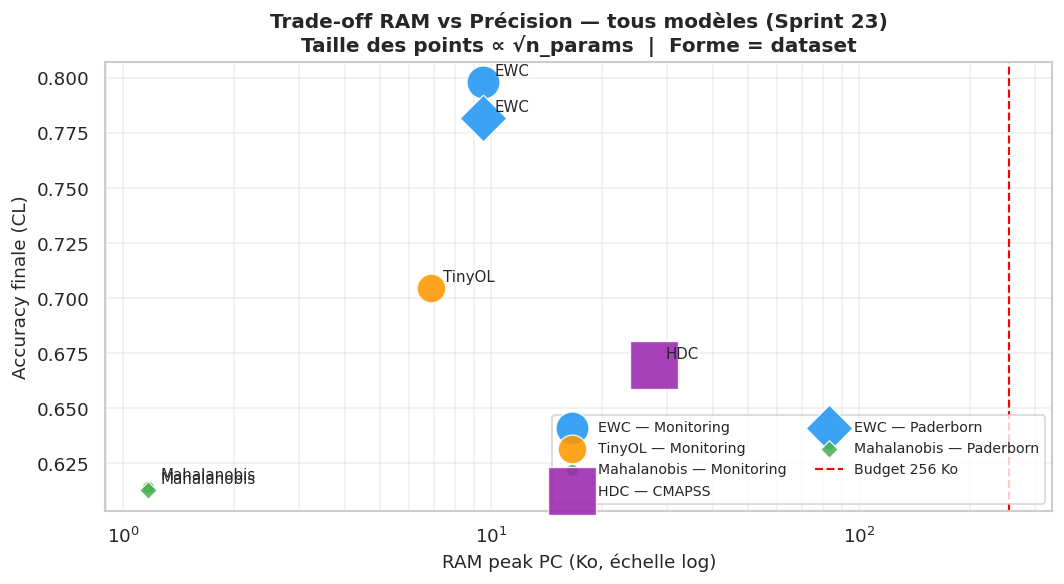

In [7]:
# --- 6. Scatter RAM vs Accuracy — Trade-off taille/performance ---
# Données Sprint 23 (classification — acc_final + ram_peak_bytes disponibles)
scatter_entries = [
    {"exp": "exp_S23_01", "model": "EWC",        "dataset": "Monitoring"},
    {"exp": "exp_S23_02", "model": "TinyOL",      "dataset": "Monitoring"},
    {"exp": "exp_S23_03", "model": "Mahalanobis", "dataset": "Monitoring"},
    {"exp": "exp_S23_04", "model": "HDC",         "dataset": "CMAPSS"},
    {"exp": "exp_S23_05", "model": "EWC",         "dataset": "Paderborn"},
    {"exp": "exp_S23_06", "model": "Mahalanobis", "dataset": "Paderborn"},
]
for e in scatter_entries:
    d = json.loads((EXP / e["exp"] / "results.json").read_text())
    e.update({"ram_kb": d["ram_peak_bytes"] / 1024, "acc": d["acc_final"], "n_params": d["n_params"]})

MODEL_COLORS = {"EWC": "#2196F3", "TinyOL": "#FF9800", "Mahalanobis": "#4CAF50", "HDC": "#9C27B0"}
DS_MARKERS   = {"Monitoring": "o", "CMAPSS": "s", "Paderborn": "D"}

fig, ax = plt.subplots(figsize=(9, 5))
seen = set()
for e in scatter_entries:
    lbl = f'{e["model"]} — {e["dataset"]}'
    ax.scatter(e["ram_kb"], e["acc"],
               s=np.sqrt(e["n_params"]) * 10,
               c=MODEL_COLORS[e["model"]], marker=DS_MARKERS[e["dataset"]],
               alpha=0.88, edgecolors="white", linewidths=0.8, zorder=3,
               label=lbl if lbl not in seen else "_nolegend_")
    seen.add(lbl)
    ax.annotate(e["model"], (e["ram_kb"], e["acc"]),
                textcoords="offset points", xytext=(7, 4), fontsize=9)

ax.axvline(256, color="red", linestyle="--", linewidth=1.3, label="Budget 256 Ko", zorder=2)
ax.set_xscale("log")
ax.set_xlabel("RAM peak PC (Ko, échelle log)", fontsize=11)
ax.set_ylabel("Accuracy finale (CL)", fontsize=11)
ax.set_title("Trade-off RAM vs Précision — tous modèles (Sprint 23)\n"
             "Taille des points ∝ √n_params  |  Forme = dataset",
             fontweight="bold")
ax.legend(fontsize=8.5, ncol=2, loc="lower right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "ram_vs_accuracy_scatter.png", bbox_inches="tight", dpi=150)
plt.show()

## 7. Décomposition RAM — Inférence vs Entraînement estimé

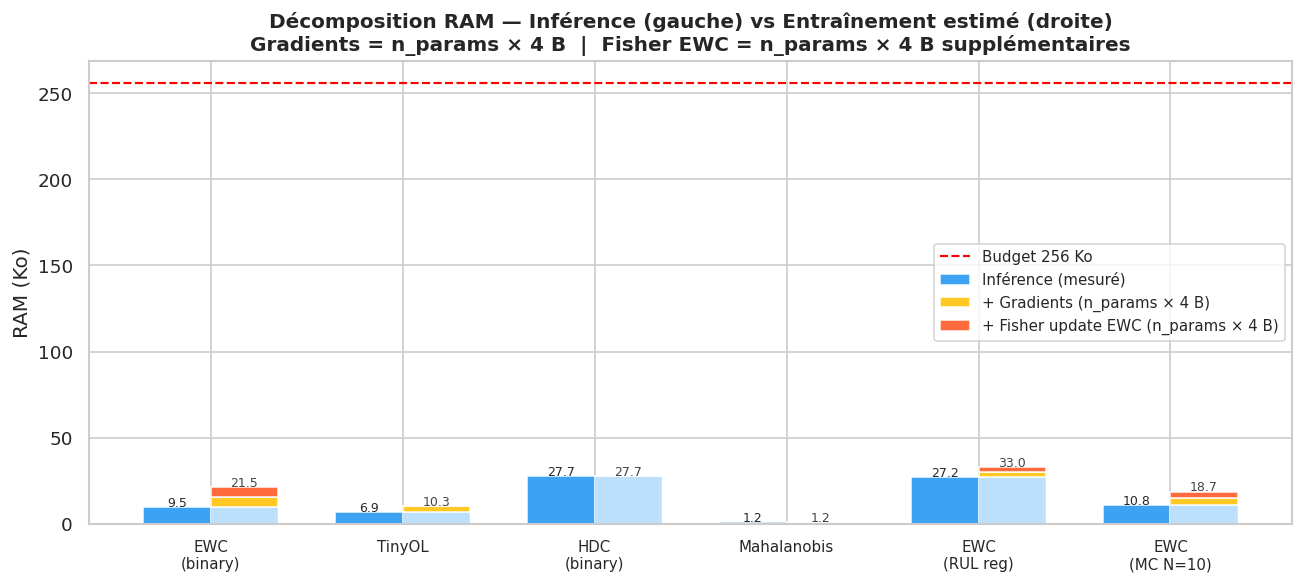

Note : les valeurs tracemalloc (Python) sous-estiment la mémoire réelle des tenseurs PyTorch.


In [8]:
# --- 7. Décomposition RAM — Inférence vs Entraînement estimé ---
# Inférence  = ram_peak_bytes (mesuré tracemalloc)
# Entraînement = inférence + gradients (n_params×4) + Fisher update EWC (n_params×4)
models_ram = [
    {"label": "EWC\n(binary)",  "n_params": 1538, "ram_inf": 9728,  "has_grad": True,  "has_fisher": True},
    {"label": "TinyOL",         "n_params": 881,  "ram_inf": 7040,  "has_grad": True,  "has_fisher": False},
    {"label": "HDC\n(binary)",  "n_params": 7000, "ram_inf": 28364, "has_grad": False, "has_fisher": False},
    {"label": "Mahalanobis",    "n_params": 30,   "ram_inf": 1200,  "has_grad": False, "has_fisher": False},
    {"label": "EWC\n(RUL reg)", "n_params": 737,  "ram_inf": 27892, "has_grad": True,  "has_fisher": True},
    {"label": "EWC\n(MC N=10)", "n_params": 1018, "ram_inf": 11019, "has_grad": True,  "has_fisher": True},
]
for m in models_ram:
    m["grad_extra"]   = m["n_params"] * 4 if m["has_grad"] else 0
    m["fisher_extra"] = m["n_params"] * 4 if m["has_fisher"] else 0
    m["ram_train"]    = m["ram_inf"] + m["grad_extra"] + m["fisher_extra"]

labels_r = [m["label"] for m in models_ram]
xr = np.arange(len(labels_r))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

# Barre gauche : inférence
bars_inf = ax.bar(xr - w/2, [m["ram_inf"]/1024 for m in models_ram],
                  w, label="Inférence (mesuré)", color="#2196F3", alpha=0.88, edgecolor="white")
# Barre droite : entraînement (fond bleu transparent + couches extras)
ax.bar(xr + w/2, [m["ram_inf"]/1024 for m in models_ram],
       w, color="#2196F3", alpha=0.30, edgecolor="white")
ax.bar(xr + w/2, [m["grad_extra"]/1024 for m in models_ram],
       w, bottom=[m["ram_inf"]/1024 for m in models_ram],
       label="+ Gradients (n_params × 4 B)", color="#FFC107", alpha=0.88, edgecolor="white")
ax.bar(xr + w/2, [m["fisher_extra"]/1024 for m in models_ram],
       w, bottom=[(m["ram_inf"] + m["grad_extra"])/1024 for m in models_ram],
       label="+ Fisher update EWC (n_params × 4 B)", color="#FF5722", alpha=0.88, edgecolor="white")

ax.axhline(256, color="red", linestyle="--", linewidth=1.3, label="Budget 256 Ko", zorder=2)

for bar, m in zip(bars_inf, models_ram):
    ax.text(bar.get_x() + bar.get_width()/2, m["ram_inf"]/1024 + 0.3,
            f"{m['ram_inf']/1024:.1f}", ha="center", fontsize=7.5)
for i, m in enumerate(models_ram):
    total_t = m["ram_train"] / 1024
    ax.text(xr[i] + w/2, total_t + 0.3, f"{total_t:.1f}",
            ha="center", fontsize=7.5, color="#444")

ax.set_xticks(xr)
ax.set_xticklabels(labels_r, fontsize=9)
ax.set_ylabel("RAM (Ko)")
ax.set_title("Décomposition RAM — Inférence (gauche) vs Entraînement estimé (droite)\n"
             "Gradients = n_params × 4 B  |  Fisher EWC = n_params × 4 B supplémentaires",
             fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "ram_breakdown_infer_vs_train.png", bbox_inches="tight", dpi=150)
plt.show()
print("Note : les valeurs tracemalloc (Python) sous-estiment la mémoire réelle des tenseurs PyTorch.")

## 8. MACs — Complexité calculatoire (inférence + entraînement + Pareto)

Complexité calculée analytiquement via `src/evaluation/compute_cost.py` — pas stockée dans les JSON.
Paramètres board : 200 samples/tâche, online (1 epoch), architecture configs Sprint 23.

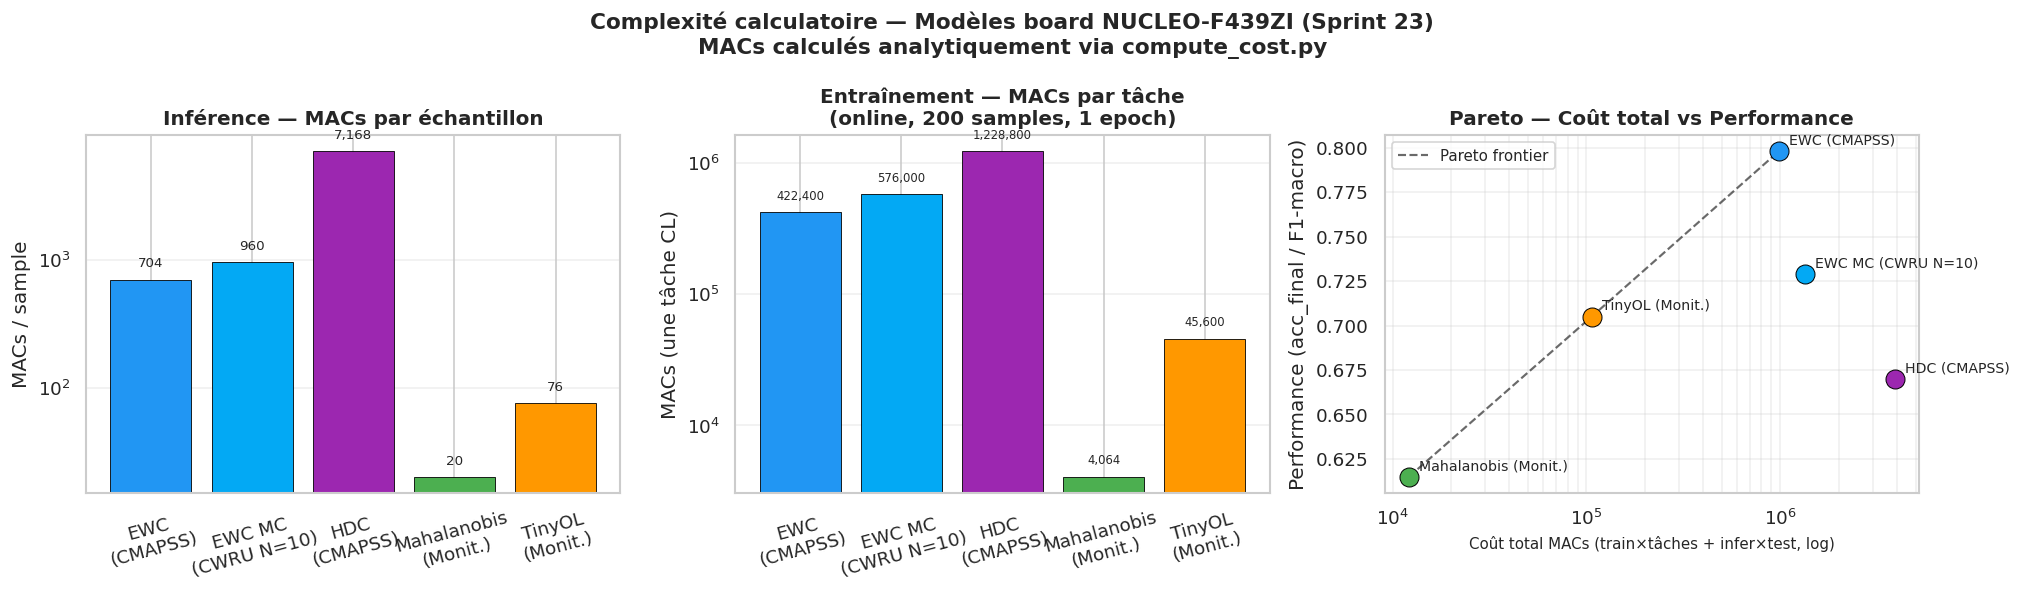

  EWC (CMAPSS)           infer=   704  train/task=   422,400  total=     985,600
  EWC MC (CWRU N=10)     infer=   960  train/task=   576,000  total=   1,344,000
  HDC (CMAPSS)           infer= 7,168  train/task= 1,228,800  total=   3,891,200
  Mahalanobis (Monit.)   infer=    20  train/task=     4,064  total=      12,128
  TinyOL (Monit.)        infer=    76  train/task=    45,600  total=     106,400


In [9]:
# --- 8. MACs — Complexité calculatoire (inférence + entraînement + Pareto) ---
import sys
sys.path.insert(0, str(ROOT / "src"))
from evaluation.compute_cost import (
    macs_ewc_mlp, macs_hdc, macs_mahalanobis, macs_tinyol,
    training_macs_ewc, training_macs_hdc,
    training_macs_mahalanobis, training_macs_tinyol,
)

N_SAMP  = 200  # samples par tâche (board, online, Sprint 23)
N_TASKS = 2    # tâches CL standard Sprint 23
N_TEST  = 200  # samples de test (Pareto)

_INFER_MACS = {
    "EWC\n(CMAPSS)":         macs_ewc_mlp(5, [32, 16], 2),
    "EWC MC\n(CWRU N=10)":   macs_ewc_mlp(9, [32, 16], 10),
    "HDC\n(CMAPSS)":         macs_hdc(5, 1024, 2),
    "Mahalanobis\n(Monit.)": macs_mahalanobis(4),
    "TinyOL\n(Monit.)":      macs_tinyol(4, [8, 4, 2], 2),
}
_TRAIN_MACS = {  # MACs pour UNE tâche CL (online, 1 epoch)
    "EWC\n(CMAPSS)":         training_macs_ewc(5, [32, 16], 2,  N_SAMP, 1, 1),
    "EWC MC\n(CWRU N=10)":   training_macs_ewc(9, [32, 16], 10, N_SAMP, 1, 1),
    "HDC\n(CMAPSS)":         training_macs_hdc(5, 1024, N_SAMP),
    "Mahalanobis\n(Monit.)": training_macs_mahalanobis(4, N_SAMP),
    "TinyOL\n(Monit.)":      training_macs_tinyol(4, [8, 4, 2], 2, N_SAMP, 1),
}
_ACC = {  # acc_final (classification) ou f1_macro (EWC MC)
    "EWC\n(CMAPSS)":         0.798,
    "EWC MC\n(CWRU N=10)":   0.729,
    "HDC\n(CMAPSS)":         0.670,
    "Mahalanobis\n(Monit.)": 0.615,
    "TinyOL\n(Monit.)":      0.705,
}
_COLORS_M = {
    "EWC\n(CMAPSS)":         "#2196F3",
    "EWC MC\n(CWRU N=10)":   "#03A9F4",
    "HDC\n(CMAPSS)":         "#9C27B0",
    "Mahalanobis\n(Monit.)": "#4CAF50",
    "TinyOL\n(Monit.)":      "#FF9800",
}
MORDER = list(_INFER_MACS.keys())

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# — Plot 1 : Inférence MACs/sample —
ax = axes[0]
bars = ax.bar(MORDER, [_INFER_MACS[m] for m in MORDER],
              color=[_COLORS_M[m] for m in MORDER], edgecolor="black", linewidth=0.5)
for bar, m in zip(bars, MORDER):
    v = _INFER_MACS[m]
    ax.text(bar.get_x() + bar.get_width()/2, v * 1.25, f"{v:,}",
            ha="center", fontsize=8)
ax.set_yscale("log"); ax.set_ylabel("MACs / sample")
ax.set_title("Inférence — MACs par échantillon", fontweight="bold")
ax.tick_params(axis="x", rotation=15); ax.grid(axis="y", alpha=0.3)

# — Plot 2 : Entraînement MACs par tâche —
ax = axes[1]
bars2 = ax.bar(MORDER, [_TRAIN_MACS[m] for m in MORDER],
               color=[_COLORS_M[m] for m in MORDER], edgecolor="black", linewidth=0.5)
for bar, m in zip(bars2, MORDER):
    v = _TRAIN_MACS[m]
    ax.text(bar.get_x() + bar.get_width()/2, v * 1.25, f"{v:,.0f}",
            ha="center", fontsize=7)
ax.set_yscale("log"); ax.set_ylabel("MACs (une tâche CL)")
ax.set_title(f"Entraînement — MACs par tâche\n(online, {N_SAMP} samples, 1 epoch)", fontweight="bold")
ax.tick_params(axis="x", rotation=15); ax.grid(axis="y", alpha=0.3)

# — Plot 3 : Pareto total MACs vs Performance —
ax = axes[2]
points = []
for m in MORDER:
    total = _TRAIN_MACS[m] * N_TASKS + _INFER_MACS[m] * N_TEST
    acc   = _ACC[m]
    points.append((total, acc, m))
    ax.scatter(total, acc, color=_COLORS_M[m], s=130, zorder=5,
               edgecolor="black", linewidth=0.6)
    ax.annotate(m.replace("\n", " "), (total, acc),
                textcoords="offset points", xytext=(6, 4), fontsize=8.5)

# Pareto frontier (meilleure performance pour un coût donné)
sorted_pts = sorted(points, key=lambda x: x[0])
px, py, best = [], [], -1.0
for cost, acc_v, _ in sorted_pts:
    if acc_v >= best:
        px.append(cost); py.append(acc_v); best = acc_v
if len(px) > 1:
    ax.plot(px, py, "k--", lw=1.3, alpha=0.65, label="Pareto frontier")

ax.set_xscale("log")
ax.set_xlabel("Coût total MACs (train×tâches + infer×test, log)", fontsize=9)
ax.set_ylabel("Performance (acc_final / F1-macro)")
ax.set_title("Pareto — Coût total vs Performance", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which="both")

fig.suptitle("Complexité calculatoire — Modèles board NUCLEO-F439ZI (Sprint 23)\n"
             "MACs calculés analytiquement via compute_cost.py",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "macs_complexity_pareto.png", bbox_inches="tight", dpi=150)
plt.show()
for m in MORDER:
    total = _TRAIN_MACS[m] * N_TASKS + _INFER_MACS[m] * N_TEST
    print(f"  {m.replace(chr(10),' '):22} infer={_INFER_MACS[m]:>6,}  train/task={_TRAIN_MACS[m]:>10,}  total={total:>12,}")

## 9. Accuracy Matrices board — Sprint 23 (NUCLEO-F439ZI)

`acc_matrix[i][j]` = accuracy sur tâche j après entraînement sur les tâches 0..i.
Données mesurées sur board (`platform: "nucleo_f439zi"`) — pas une simulation PC.

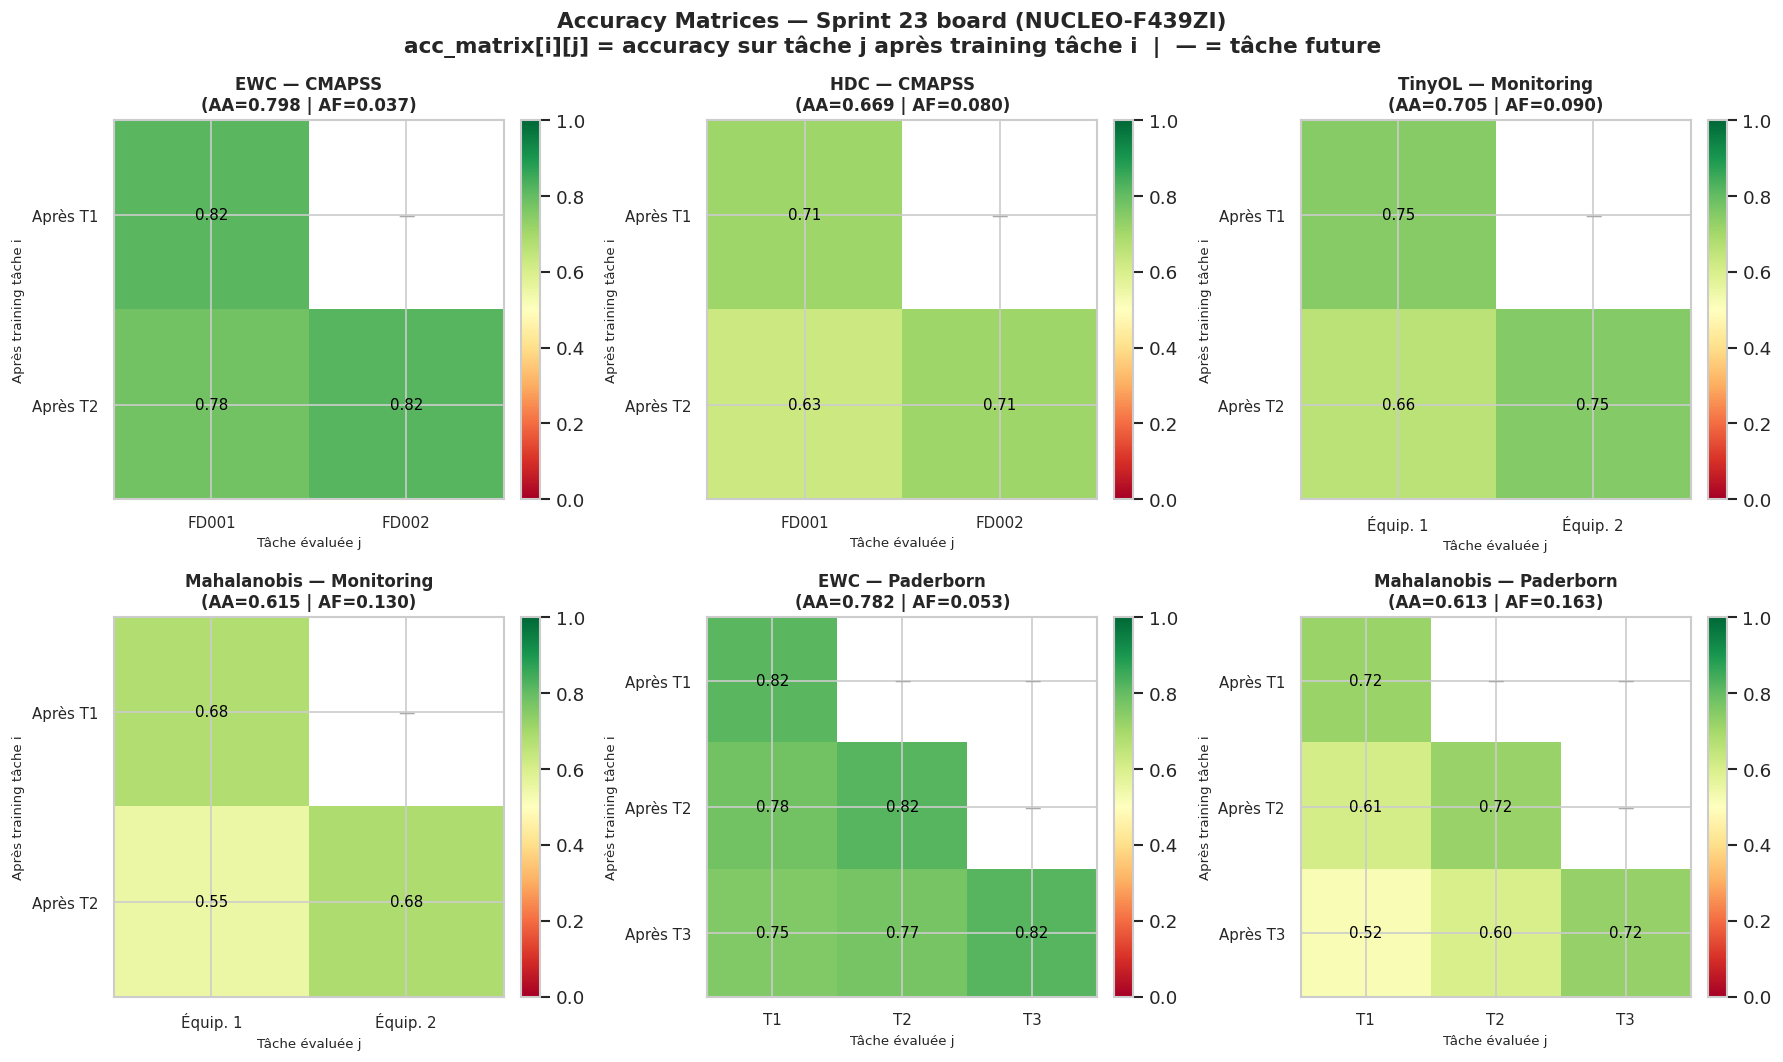

In [10]:
# --- 9. Accuracy Matrices board — Sprint 23 (NUCLEO-F439ZI) ---
# acc_matrix[i][j] = accuracy sur tâche j après training tâche i
# platform: "nucleo_f439zi" vérifié dans tous les JSONs S23_01..06

S23_EXPS = [
    {"exp": "exp_S23_01", "model": "EWC",        "dataset": "CMAPSS",     "tasks": ["FD001", "FD002"]},
    {"exp": "exp_S23_04", "model": "HDC",         "dataset": "CMAPSS",     "tasks": ["FD001", "FD002"]},
    {"exp": "exp_S23_02", "model": "TinyOL",      "dataset": "Monitoring", "tasks": ["Équip. 1", "Équip. 2"]},
    {"exp": "exp_S23_03", "model": "Mahalanobis", "dataset": "Monitoring", "tasks": ["Équip. 1", "Équip. 2"]},
    {"exp": "exp_S23_05", "model": "EWC",         "dataset": "Paderborn",  "tasks": ["T1", "T2", "T3"]},
    {"exp": "exp_S23_06", "model": "Mahalanobis", "dataset": "Paderborn",  "tasks": ["T1", "T2", "T3"]},
]
for e in S23_EXPS:
    raw = json.loads((EXP / e["exp"] / "results.json").read_text())
    n   = raw["n_tasks"]
    mat = np.full((n, n), np.nan)
    for i, row in enumerate(raw["acc_matrix"]):
        for j, v in enumerate(row):
            if v is not None:
                mat[i, j] = v
    e["mat"] = mat
    e["aa"]  = raw["acc_final"]
    e["af"]  = raw["avg_forgetting"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
cmap_mat = plt.get_cmap("RdYlGn")
for ax, e in zip(axes.flat, S23_EXPS):
    mat = e["mat"]
    n   = mat.shape[0]
    im  = ax.imshow(mat, vmin=0, vmax=1, cmap=cmap_mat, aspect="auto")
    ax.set_title(f"{e['model']} — {e['dataset']}\n(AA={e['aa']:.3f} | AF={e['af']:.3f})",
                 fontsize=10, fontweight="bold")
    ax.set_xticks(range(n)); ax.set_xticklabels(e["tasks"], fontsize=9)
    ax.set_yticks(range(n))
    ax.set_yticklabels([f"Après T{i+1}" for i in range(n)], fontsize=9)
    ax.set_xlabel("Tâche évaluée j", fontsize=8)
    ax.set_ylabel("Après training tâche i", fontsize=8)
    for i in range(n):
        for j in range(n):
            v = mat[i, j]
            if not np.isnan(v):
                col = "white" if v < 0.5 else "black"
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, color=col)
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=10, color="#aaa")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Accuracy Matrices — Sprint 23 board (NUCLEO-F439ZI)\n"
             "acc_matrix[i][j] = accuracy sur tâche j après training tâche i  |  — = tâche future",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "acc_matrices_board_s23.png", bbox_inches="tight", dpi=150)
plt.show()

## Récapitulatif figures générées

In [11]:
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures sauvegardées dans {FIG_DIR}:")
for f in figs:
    print(f"  {f.name}")


9 figures sauvegardées dans ../experiments/figures/sprint25:
  acc_matrices_board_s23.png
  cwru_per_class_accuracy.png
  horizon_score_cmapss.png
  macs_complexity_pareto.png
  multiclass_cwru_f1_progression.png
  ram_breakdown_infer_vs_train.png
  ram_vs_accuracy_scatter.png
  rul_rmse_by_task.png
  s25_memory_latency_profiling.png
